In [1]:
import os
os.chdir('../..')

In [ ]:
import selfies as sf
from scipy.spatial.distance import cosine, euclidean
from src.datasets import QM9Dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import polars as pl
from rdkit import DataStructs, Chem
from rdkit.Chem import AllChem
from src.clusters import ClusterAnalysis

/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-17 15:34:05.673 | INFO     | utils.file_ops:get_device:36 - Using Apple Silicon (MPS)


In [3]:
qm9 = QM9Dataset()
qm9.load()

2026-02-17 15:34:07.005 | INFO     | src.datasets:load:65 - Loading QM9 from data/QM9/dataset_cleaned.csv...


mol_id,smiles,canonical_smiles,selfies,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp3,h_bond_donors,h_bond_acceptors,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C
str,str,str,str,i64,str,f64,f64,f64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""qm9_853""","""c1c(C)oc(N)n1""","""Cc1cnc(N)o1""","""[C][C][=C][N][=C][Branch1][C][…",13,"""Aromatic""",98.105,0.56522,52.05,7,1,1,0,0.25,1,3,0,0,0,1,0,0,0,0,0,0,3,1.9777,56.830002,-5.423229,0.876207,6.299436,716.514771,2.80827,-9270.367188,-9270.191406,-9270.165039,-9271.185547,23.815001,-56.020008,-56.344635,-56.653049,-52.289814,6.80587,2.19976,1.68265
"""qm9_1912""","""CC[C@@H]1OC(=O)C1""","""CC[C@H]1CC(=O)O1""","""[C][C][C@H1][C][C][=Branch1][C…",15,"""Aliphatic Ring""",100.117,0.7119,26.3,7,1,0,1,0.8,0,2,0,0,0,0,0,0,1,0,1,0,2,4.1185,57.540001,-7.439593,0.345585,7.787898,849.958191,3.396253,-9406.761719,-9406.572266,-9406.545898,-9407.612305,25.061001,-63.319294,-63.707142,-64.066956,-59.057423,6.91956,1.63045,1.44116
"""qm9_1391""","""C(=O)N/C(=N/C)N""","""C/N=C(\N)NC=O""","""[C][/N][=C][Branch1][C][\N][N]…",14,"""Acyclic""",101.109,-1.3231,67.48,7,0,0,1,0.333333,2,2,0,0,0,1,1,0,0,0,0,0,4,0.6445,59.34,-6.160658,-0.234018,5.92664,871.848083,3.092547,-9739.895508,-9739.6875,-9739.661133,-9740.759766,26.863001,-56.495552,-56.826496,-57.160625,-52.508537,7.79216,1.57252,1.32188
"""qm9_1445""","""C(=O)C[C@H](C)CC""","""CC[C@@H](C)CC=O""","""[C][C][C@@H1][Branch1][C][C][C…",19,"""Acyclic""",100.161,1.6215,17.07,7,0,0,3,0.833333,0,1,0,0,0,0,0,0,0,0,0,0,1,2.8115,68.5,-6.732097,-0.522459,6.209638,1111.150146,4.600684,-8461.113281,-8460.869141,-8460.84375,-8462.037109,31.146999,-75.966255,-76.454369,-76.917046,-70.629799,6.54277,1.1887,1.08159
"""qm9_617""","""N1C[C@@H]1C(=O)C""","""CC(=O)[C@H]1CN1""","""[C][C][=Branch1][C][=O][C@H1][…",13,"""Aliphatic Ring""",85.106,-0.4528,39.01,6,1,0,1,0.75,1,2,0,0,0,0,0,0,0,1,0,0,2,2.4621,50.98,-6.993326,-0.64491,6.351138,575.191895,2.931428,-7795.694824,-7795.522461,-7795.496582,-7796.512695,21.929001,-53.0369,-53.365181,-53.673595,-49.426605,7.41334,2.70699,2.32818
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""qm9_1079""","""OC(C)(C)[C@H](O)C""","""C[C@@H](O)C(C)(C)O""","""[C][C@@H1][Branch1][C][O][C][B…",19,"""Acyclic""",104.149,0.1381,40.46,7,0,0,1,1.0,2,2,0,2,0,0,0,0,0,0,0,0,2,1.6833,63.110001,-7.110335,1.763298,8.873632,803.22998,4.577635,-9471.249023,-9471.0,-9470.973633,-9472.132812,34.300999,-73.353714,-73.83609,-74.29879,-67.965775,3.14334,2.26158,1.89442
"""qm9_145""","""CCC1CC1""","""CCC1CC1""","""[C][C][C][C][C][Ring1][Ring1]""",15,"""Aliphatic Ring""",70.135,1.8064,0.0,5,1,0,1,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.095,52.900002,-7.40966,2.683043,10.092703,514.305298,3.747688,-5344.460938,-5344.299805,-5344.273926,-5345.246094,21.364,-59.014156,-59.430954,-59.790852,-54.921043,11.92252,3.07744,2.77702
"""qm9_393""","""C[C@]1(C#N)OC1""","""C[C@@]1(C#N)CO1""","""[C][C@@][Branch1][Ring1][C][#N…",11,"""Aliphatic Ring""",83.09,0.29888,36.32,6,1,0,0,0.75,0,2,0,0,0,0,0,0,0,0,1,0,2,3.8379,47.200001,-8.182464,0.084355,8.266819,525.817993,2.277702,-7762.89209,-7762.729492,-7762.703613,-7763.688477,20.903,-47.460442,-47.721455,-47.97847,-44.408089,5.99149,3.23476,2.47902


# Morgan Fingerprints

In [4]:
qm9.add_morgan_fingerprints(radius=3, fp_size=2048)

2026-02-17 15:31:34.134 | INFO     | src.features:compute_morgan_fingerprints:56 - Computing Morgan Fingerprints (Radius=3, Size=2048)...


In [5]:
qm9.df

mol_id,smiles,canonical_smiles,selfies,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp3,h_bond_donors,h_bond_acceptors,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,morgan_fingerprint
str,str,str,str,i64,str,f64,f64,f64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[i8]
"""qm9_853""","""c1c(C)oc(N)n1""","""Cc1cnc(N)o1""","""[C][C][=C][N][=C][Branch1][C][…",13,"""Aromatic""",98.105,0.56522,52.05,7,1,1,0,0.25,1,3,0,0,0,1,0,0,0,0,0,0,3,1.9777,56.830002,-5.423229,0.876207,6.299436,716.514771,2.80827,-9270.367188,-9270.191406,-9270.165039,-9271.185547,23.815001,-56.020008,-56.344635,-56.653049,-52.289814,6.80587,2.19976,1.68265,"[0, 0, … 0]"
"""qm9_1912""","""CC[C@@H]1OC(=O)C1""","""CC[C@H]1CC(=O)O1""","""[C][C][C@H1][C][C][=Branch1][C…",15,"""Aliphatic Ring""",100.117,0.7119,26.3,7,1,0,1,0.8,0,2,0,0,0,0,0,0,1,0,1,0,2,4.1185,57.540001,-7.439593,0.345585,7.787898,849.958191,3.396253,-9406.761719,-9406.572266,-9406.545898,-9407.612305,25.061001,-63.319294,-63.707142,-64.066956,-59.057423,6.91956,1.63045,1.44116,"[0, 0, … 0]"
"""qm9_1391""","""C(=O)N/C(=N/C)N""","""C/N=C(\N)NC=O""","""[C][/N][=C][Branch1][C][\N][N]…",14,"""Acyclic""",101.109,-1.3231,67.48,7,0,0,1,0.333333,2,2,0,0,0,1,1,0,0,0,0,0,4,0.6445,59.34,-6.160658,-0.234018,5.92664,871.848083,3.092547,-9739.895508,-9739.6875,-9739.661133,-9740.759766,26.863001,-56.495552,-56.826496,-57.160625,-52.508537,7.79216,1.57252,1.32188,"[0, 0, … 0]"
"""qm9_1445""","""C(=O)C[C@H](C)CC""","""CC[C@@H](C)CC=O""","""[C][C][C@@H1][Branch1][C][C][C…",19,"""Acyclic""",100.161,1.6215,17.07,7,0,0,3,0.833333,0,1,0,0,0,0,0,0,0,0,0,0,1,2.8115,68.5,-6.732097,-0.522459,6.209638,1111.150146,4.600684,-8461.113281,-8460.869141,-8460.84375,-8462.037109,31.146999,-75.966255,-76.454369,-76.917046,-70.629799,6.54277,1.1887,1.08159,"[0, 1, … 0]"
"""qm9_617""","""N1C[C@@H]1C(=O)C""","""CC(=O)[C@H]1CN1""","""[C][C][=Branch1][C][=O][C@H1][…",13,"""Aliphatic Ring""",85.106,-0.4528,39.01,6,1,0,1,0.75,1,2,0,0,0,0,0,0,0,1,0,0,2,2.4621,50.98,-6.993326,-0.64491,6.351138,575.191895,2.931428,-7795.694824,-7795.522461,-7795.496582,-7796.512695,21.929001,-53.0369,-53.365181,-53.673595,-49.426605,7.41334,2.70699,2.32818,"[0, 0, … 0]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""qm9_1079""","""OC(C)(C)[C@H](O)C""","""C[C@@H](O)C(C)(C)O""","""[C][C@@H1][Branch1][C][O][C][B…",19,"""Acyclic""",104.149,0.1381,40.46,7,0,0,1,1.0,2,2,0,2,0,0,0,0,0,0,0,0,2,1.6833,63.110001,-7.110335,1.763298,8.873632,803.22998,4.577635,-9471.249023,-9471.0,-9470.973633,-9472.132812,34.300999,-73.353714,-73.83609,-74.29879,-67.965775,3.14334,2.26158,1.89442,"[0, 1, … 0]"
"""qm9_145""","""CCC1CC1""","""CCC1CC1""","""[C][C][C][C][C][Ring1][Ring1]""",15,"""Aliphatic Ring""",70.135,1.8064,0.0,5,1,0,1,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.095,52.900002,-7.40966,2.683043,10.092703,514.305298,3.747688,-5344.460938,-5344.299805,-5344.273926,-5345.246094,21.364,-59.014156,-59.430954,-59.790852,-54.921043,11.92252,3.07744,2.77702,"[0, 0, … 0]"
"""qm9_393""","""C[C@]1(C#N)OC1""","""C[C@@]1(C#N)CO1""","""[C][C@@][Branch1][Ring1][C][#N…",11,"""Aliphatic Ring""",83.09,0.29888,36.32,6,1,0,0,0.75,0,2,0,0,0,0,0,0,0,0,1,0,2,3.8379,47.200001,-8.182464,0.084355,8.266819,525.817993,2.277702,-7762.89209,-7762.729492,-7762.703613,-7763.688477,20.903,-47.460442,-47.721455,-47.97847,-44.408089,5.99149,3.23476,2.47902,"[0, 0, … 0]"


In [6]:
df_morgan = qm9.df['morgan_fingerprint']
df_morgan_list = list(df_morgan)

validating that it has done it correct. 

In [7]:
for _, ls in enumerate(df_morgan_list[0:4]):
    for i, val in enumerate(ls):
        if val == 1:
            print(i)

47
378
383
480
656
917
1009
1057
1171
1184
1203
1380
1452
1457
1535
1604
1722
1742
1873
80
231
294
314
354
591
650
656
750
926
970
1019
1057
1233
1235
1380
1391
1454
1950
126
140
260
285
334
650
683
689
694
725
807
943
978
1004
1057
1152
1171
1685
1789
1
80
95
283
294
509
599
650
694
763
1004
1057
1157
1256
1291
1544
2002


# Validate One-Hot and Transformer embeddings

In [4]:
qm9.add_selfies_transformer()
qm9.add_selfies_onehot()

2026-02-17 15:34:08.104 | INFO     | src.features:compute_selfies_transformer:68 - Computing Transformer Embeddings (seyonec/ChemBERTa-zinc-base-v1)...
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2800.83it/s, Materializing param=pooler.dense.weight]                             
2026-02-17 15:34:23.301 | INFO     | src.features:compute_selfies_onehot:93 - Computing One-Hot Encodings...


In [6]:
qm9.df.select(
    pl.col("selfies_onehot")
    .explode()        # explode outer list (sequence positions)
    .explode()        # explode inner list (vector entries)
    .unique()
)

selfies_onehot
i64
0
1


In [ ]:
onehot_matrix = qm9.df["selfies_onehot"][0]

print(f"Number of tokens (Sequence Length): {len(onehot_matrix)}")
print(f"Vocabulary Size (Tokens in alphabet): {len(onehot_matrix[0])}")

is_valid = all(sum(row) == 1 for row in onehot_matrix)
print(f"Is strictly one-hot: {is_valid}")

smiles = qm9.df["canonical_smiles"][0] # e.g., "C"
selfie_str = sf.encoder(smiles)    # e.g., "[C]"
print(f"SELFIES: {selfie_str}")
print(f"Tokens: {list(sf.split_selfies(selfie_str))}") # Should match matrix row count (plus padding)

Number of tokens (Sequence Length): 15
Vocabulary Size (Tokens in alphabet): 39
Is strictly one-hot: True
SELFIES: [C]
Tokens: ['[C]']


In [ ]:
transformer_vec = qm9.df["selfies_transformer"][0]
print(f"Embedding dimension: {len(transformer_vec)}") # Should be 768

vec_0 = qm9.df["selfies_transformer"][0]
vec_1 = qm9.df["selfies_transformer"][1]

# Check if they are actually different
print(f"Are vectors identical? {vec_0 == vec_1}")

# Similarity = 1 - distance
similarity = 1 - cosine(qm9.df["selfies_transformer"][0], qm9.df["selfies_transformer"][1])
print(f"Similarity between first two molecules: {similarity}")

Embedding dimension: 768
Are vectors identical? shape: (768,)
Series: '' [bool]
[
	false
	false
	false
	false
	false
	…
	false
	false
	false
	false
	false
]
Similarity between first two molecules: 0.7993101949537702


In [ ]:
# Check for nulls
null_counts = qm9.df.select([
    pl.col("selfies_onehot").is_null().sum().alias("onehot_nulls"),
    pl.col("selfies_transformer").is_null().sum().alias("transformer_nulls")
])
print(null_counts)

# Check if any transformer vectors are all zeros (indicating a failure in the model pass)
all_zeros = all(v == 0 for v in qm9.df["selfies_transformer"][0])
print(f"Is first transformer vector empty/zeros? {all_zeros}")

shape: (1, 2)
┌──────────────┬───────────────────┐
│ onehot_nulls ┆ transformer_nulls │
│ ---          ┆ ---               │
│ u32          ┆ u32               │
╞══════════════╪═══════════════════╡
│ 0            ┆ 0                 │
└──────────────┴───────────────────┘
Is first transformer vector empty/zeros? False


# Distance metrics
## Morgan (Jaccard)

In [ ]:
def plot_distance_heatmaps(dist_morgan, dist_transformer, dist_one_hot, subset_size=100):
    """
    Plots side-by-side heatmaps for Morgan, Transformer, and One-Hot distance matrices.
    Normalizes distances to [0, 1] for visual consistency.
    """
    def normalize(m):
        m_subset = m[:subset_size, :subset_size]
        return (m_subset - np.min(m_subset)) / (np.max(m_subset) - np.min(m_subset))

    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    
    # 1. Morgan Fingerprints (Jaccard)
    sns.heatmap(
        normalize(dist_morgan), 
        ax=axes[0], 
        cmap="magma", 
        cbar_kws={'label': 'Normalized Distance'}
    )
    axes[0].set_title("Morgan (Structural)\nJaccard Distance")

    # 2. SELFIES Transformer (Euclidean)
    sns.heatmap(
        normalize(dist_transformer), 
        ax=axes[1], 
        cmap="magma", 
        cbar_kws={'label': 'Normalized Distance'}
    )
    axes[1].set_title("Transformer (Semantic)\nEuclidean Distance")

    # 3. SELFIES One-Hot (Euclidean)
    sns.heatmap(
        normalize(dist_one_hot), 
        ax=axes[2], 
        cmap="magma", 
        cbar_kws={'label': 'Normalized Distance'}
    )
    axes[2].set_title("One-Hot (String-based)\nEuclidean Distance")

    # General formatting
    for ax in axes:
        ax.set_xlabel("Molecule Index")
        ax.set_ylabel("Molecule Index")

    plt.suptitle(f"Molecular Distance Metric Comparison (First {subset_size} Molecules)", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

In [ ]:
distance_morgan = qm9.get_distance_matrix(metric='morgan', dist_type='jaccard')
distance_morgan

2026-02-11 11:31:56.449 | INFO     | src.distance:get_matrix:28 - Loading cached distance matrix from data/QM9/dist_morgan_jaccard.npy


array([[0.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [1.        , 0.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [1.        , 1.        , 0.        , ..., 1.        , 1.        ,
        1.        ],
       ...,
       [1.        , 1.        , 1.        , ..., 0.        , 0.62962963,
        0.68965517],
       [1.        , 1.        , 1.        , ..., 0.62962963, 0.        ,
        0.74193548],
       [1.        , 1.        , 1.        , ..., 0.68965517, 0.74193548,
        0.        ]], shape=(2000, 2000))

In [ ]:
# A. Check if the diagonal is all zeros (Distance to self must be 0)
diagonal_sum = np.trace(distance_morgan)
print(f"Diagonal sum (should be 0): {diagonal_sum}")

# B. Check for symmetry (Distance A->B must equal B->A)
is_symmetric = np.allclose(distance_morgan, distance_morgan.T)
print(f"Is symmetric: {is_symmetric}")

# C. Check range (Jaccard/Tanimoto distance must be between 0 and 1)
print(f"Min value: {distance_morgan.min()}, Max value: {distance_morgan.max()}")

Diagonal sum (should be 0): 0.0
Is symmetric: True
Min value: 0.0, Max value: 1.0


In [ ]:
# 1. Get fingerprints directly from the source SMILES for Row 0 and Row 1
smiles_0 = qm9.df["canonical_smiles"][0]
smiles_1 = qm9.df["canonical_smiles"][1]

mol0 = Chem.MolFromSmiles(smiles_0)
mol1 = Chem.MolFromSmiles(smiles_1)

# Generate Morgan Fingerprints (BitVectors)
radius=3
fp_size=2048
morgan_gen = AllChem.GetMorganGenerator(radius=radius, fpSize=fp_size)

fp0 = morgan_gen.GetFingerprint(mol0)
fp1 = morgan_gen.GetFingerprint(mol1)

# 2. Calculate Tanimoto Distance (1 - Similarity)
rdkit_sim = DataStructs.TanimotoSimilarity(fp0, fp1)
rdkit_dist = 1 - rdkit_sim

# 3. Compare with your matrix value
matrix_dist = distance_morgan[0, 1]

print(f"Molecules: {smiles_0} vs {smiles_1}")
print(f"RDKit Distance: {rdkit_dist}")
print(f"Matrix Distance: {matrix_dist}")
print(f"Match: {np.isclose(rdkit_dist, matrix_dist)}")

Molecules: C vs N
RDKit Distance: 1.0
Matrix Distance: 1.0
Match: True


## Selfies (Euclidian)

In [ ]:
distance_selfies_transformer = qm9.get_distance_matrix(metric='selfies_transformer', dist_type='euclidean')
distance_selfies_one_hot = qm9.get_distance_matrix(metric='selfies_onehot', dist_type='euclidean')

2026-02-11 11:31:56.566 | INFO     | src.distance:get_matrix:28 - Loading cached distance matrix from data/QM9/dist_selfies_transformer_euclidean.npy
2026-02-11 11:31:56.692 | INFO     | src.distance:get_matrix:28 - Loading cached distance matrix from data/QM9/dist_selfies_onehot_euclidean.npy


In [ ]:
# A. Check if the diagonal is all zeros (Distance to self must be 0)
diagonal_sum = np.trace(distance_selfies_transformer)
print(f"Diagonal sum (should be 0): {diagonal_sum}")

# B. Check for symmetry (Distance A -> B must equal B -> A)
is_symmetric = np.allclose(distance_selfies_transformer, distance_selfies_transformer.T, atol=1e-5)
print(f"Is symmetric: {is_symmetric}")

# C. Check for non-negativity (Euclidean distance cannot be negative)
is_non_negative = np.all(distance_selfies_transformer >= 0)
print(f"Are all values >= 0: {is_non_negative}")

Diagonal sum (should be 0): 0.0
Is symmetric: True
Are all values >= 0: True


In [ ]:
# 1. Extract the transformer embeddings for row 0 and row 1
vec_0 = np.array(qm9.df["selfies_transformer"][0])
vec_1 = np.array(qm9.df["selfies_transformer"][1])

# 2. Manually calculate Euclidean distance: sqrt(sum((vec_0 - vec_1)^2))
manual_dist = euclidean(vec_0, vec_1)

# 3. Compare with your matrix value
matrix_dist = distance_selfies_transformer[0, 1]

print(f"Manual Calculation: {manual_dist}")
print(f"Matrix Value: {matrix_dist}")
print(f"Match: {np.isclose(manual_dist, matrix_dist, atol=1e-5)}")

Manual Calculation: 16.082491997828523
Matrix Value: 16.082491997828516
Match: True


In [ ]:
dist_small_small = distance_selfies_transformer[0, 1]
dist_small_large = distance_selfies_transformer[0, 500] 

print(f"Distance (Methane to Ammonia): {dist_small_small}")
print(f"Distance (Methane to Molecule 500): {dist_small_large}")

Distance (Methane to Ammonia): 16.082491997828516
Distance (Methane to Molecule 500): 17.75199026333404


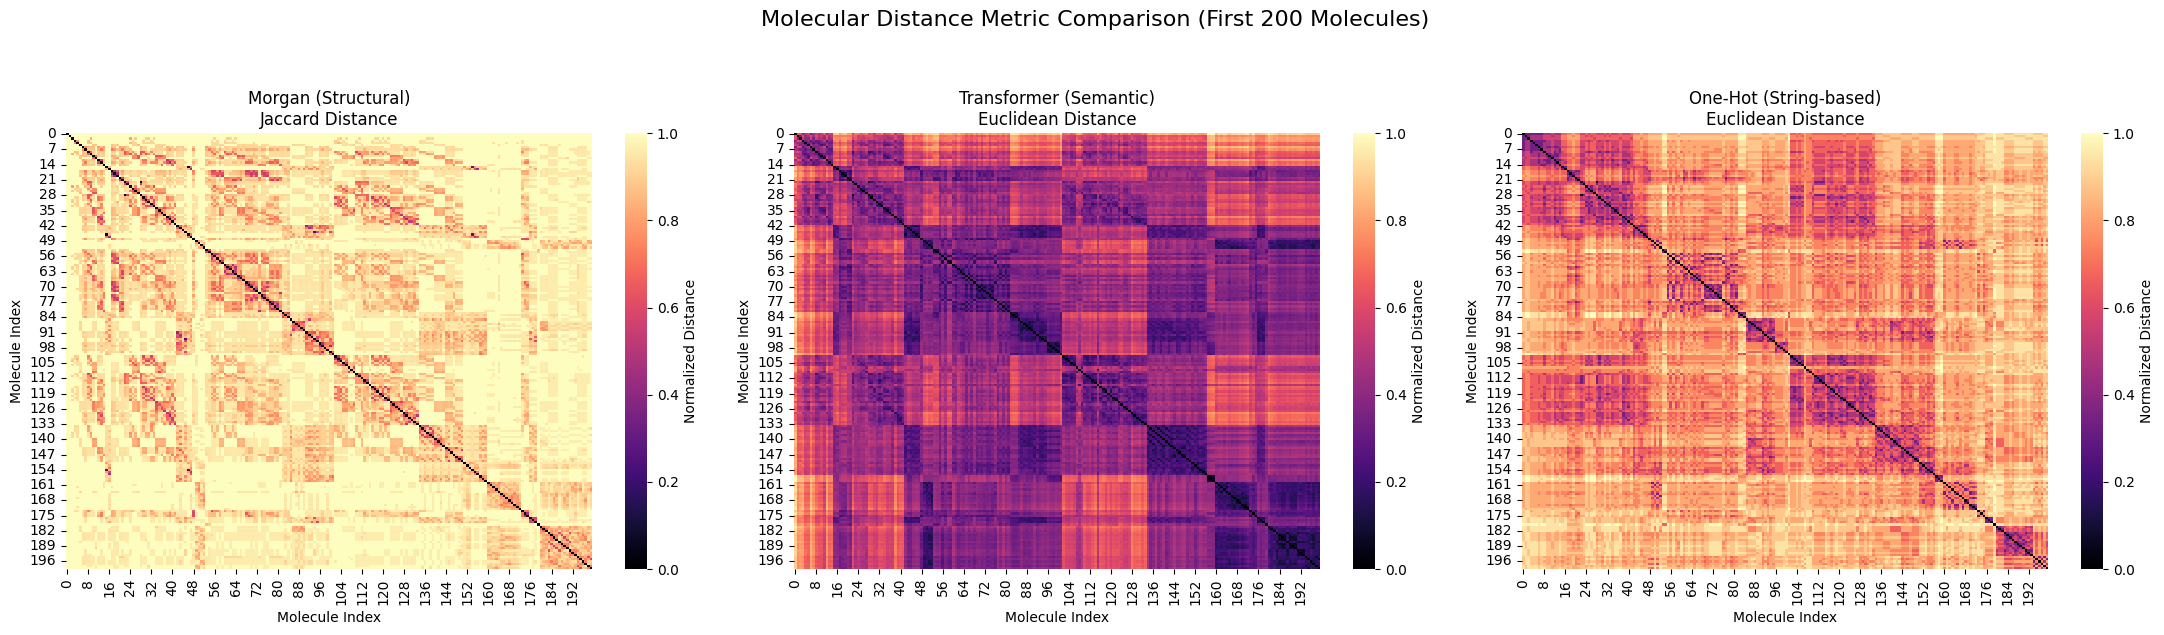

In [ ]:
plot_distance_heatmaps(distance_morgan, distance_selfies_transformer, distance_selfies_one_hot, subset_size=200)

# Clustering

## Selfies strings

In [ ]:
def find_cluster_outliers(df: pl.DataFrame, labels: np.ndarray, kmeans_model, X_matrix, top_n: int = 3):
    """
    Finds and prints the molecules furthest from their cluster centroids.
    """
    # 1. Get distances to ALL centroids for every molecule
    # Shape: (n_molecules, n_clusters)
    distances_to_all = kmeans_model.transform(X_matrix)
    
    # 2. Extract distance only to the ASSIGNED centroid
    assigned_distances = [distances_to_all[i, labels[i]] for i in range(len(labels))]
    
    # 3. Add to a temporary dataframe for easy analysis
    outlier_df = df.with_columns([
        pl.Series("cluster_id", labels),
        pl.Series("dist_to_centroid", assigned_distances)
    ])

    print(f"\n{'!'*20} CLUSTER OUTLIERS (Top {top_n} per cluster) {'!'*20}")
    
    for cluster in range(kmeans_model.n_clusters):
        # Sort by distance (descending) to find the furthest molecules
        cluster_outliers = (
            outlier_df.filter(pl.col("cluster_id") == cluster)
            .sort("dist_to_centroid", descending=True)
            .head(top_n)
        )
        
        print(f"\n[Cluster {cluster}] Furthest Molecules:")
        for row in cluster_outliers.iter_rows(named=True):
            print(f"  - {row['mol_id']} ({row['structure_class']}): "
                  f"Dist={row['dist_to_centroid']:.2f}, SMILES={row['canonical_smiles']}")

In [ ]:
def analyze_molecular_clusters(df: pl.DataFrame, method: str, n_clusters: int = 5):
    """
    Refactored to use ClusterAnalysis framework for logic,
    while keeping the custom subplots and dominant-class annotation.
    """
    # 1. Prepare Matrices (Same as before)
    X_morgan = np.array(df["morgan_fingerprint"].to_list())
    X_transformer = np.array(df["selfies_transformer"].to_list())
    
    onehot_raw = np.array(df["selfies_onehot"].to_list())
    X_onehot = onehot_raw.reshape(onehot_raw.shape[0], -1)

    datasets = {"Morgan": X_morgan, "One-Hot": X_onehot, "Transformer": X_transformer}
    # Ground Truth for Evaluation
    true_labels = df["structure_class"].to_list()
    n_clusters = len(set(true_labels))

    fig, axes = plt.subplots(1, 3, figsize=(24, 7))

    for i, (name, X) in enumerate(datasets.items()):
        print(f"\n{'='*10} ANALYZING: {name} {'='*10}")
        
        # 2. Initialize Analyzer
        analyzer = ClusterAnalysis(X, true_labels=true_labels, meta_df=df)
        
        # 3. Run Clustering (e.g., KMeans)
        if method == 'kmeans':
            labels = analyzer.run(method='kmeans', n_clusters=n_clusters)
        elif method == 'dbscan':
            labels = analyzer.run(method='dbscan', eps=0.5, min_samples=3)
        elif method == 'hierarchical':
            labels = analyzer.run(method='hierarchical', n_clusters=n_clusters, linkage='ward')
        
        if max(labels) == -1:
            print("skipping ", method)
            continue

        # 4. Evaluate
        analyzer.evaluate()
        
        #if hasattr(analyzer.model_, "transform") or hasattr(analyzer.model_, "predict"):
        #     find_cluster_outliers(df, labels, analyzer.model_, X, top_n=2)
        

        analyzer.analyze_mismatches()
        
        bad_clusters_df = analyzer.get_misclassification_report(n_neighbors=3)
        
        output_dir = f'results/cluster_reports/{name}'
        os.makedirs(output_dir, exist_ok=True)
        save_path = f'{output_dir}/cluster_outlier_report_{method}.csv'
        bad_clusters_df.write_csv(save_path)

        # 6. Custom Visualization Logic
        temp_df = df.with_columns(pl.Series("cluster_id", labels))
        
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X)
        
        ax = axes[i]
        ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab20', alpha=0.3, s=25)
        
        summary = (
            temp_df.group_by("cluster_id")
            .agg([
                pl.col("structure_class").mode().first().alias("dom_class"),
                ((pl.col("structure_class") == pl.col("structure_class").mode().first()).sum() / pl.len() * 100).alias("dom_perc")
            ])
            .sort("cluster_id")
        )
        
        # Annotate Plot
        unique_labels = sorted(list(set(labels)))
        for cluster in unique_labels:
            if cluster == -1: 
                continue

            mask = (labels == cluster)
            center_x = np.mean(X_pca[mask, 0])
            center_y = np.mean(X_pca[mask, 1])
            
            row = summary.filter(pl.col("cluster_id") == cluster)
            if not row.is_empty():
                label_text = f"{row['dom_class'][0]}\n{row['dom_perc'][0]:.0f}%"
                
                ax.text(
                    center_x, center_y, 
                    label_text, 
                    fontsize=10, weight='bold', ha='center', va='center',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.2')
                )

        ax.set_title(f"{name} Clusters", fontsize=15, fontweight='bold')

    plt.tight_layout()
    plt.show()


========== ANALYZING: Morgan ==========
--- Running KMEANS ---
Found 3 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 0.9196
Silhouette Score: 0.0592
Calinski-Harabasz Score: 105.0313

--- Mismatch Analysis ---
Visual Intruders: 13 (Look like they belong elsewhere)
Silhouette Outliers: 55 (Ambiguous assignment)
Label Mismatches: 64 (Don't match cluster's dominant class)
Finding top 3 neighbors for every molecule...
Found 64 mismatches.

========== ANALYZING: One-Hot ==========
--- Running KMEANS ---
Found 3 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 0.1698
Silhouette Score: 0.0471
Calinski-Harabasz Score: 141.0773

--- Mismatch Analysis ---
Visual Intruders: 104 (Look like they belong elsewhere)
Silhouette Outliers: 292 (Ambiguous assignment)
Label Mismatches: 794 (Don't match cluster's dominant class)
Finding top 3 neighbors for every molecule...
Found 794 mismatches.

========== ANALYZING: Transformer ==========
--- Running KMEANS ---
Found 3 cl

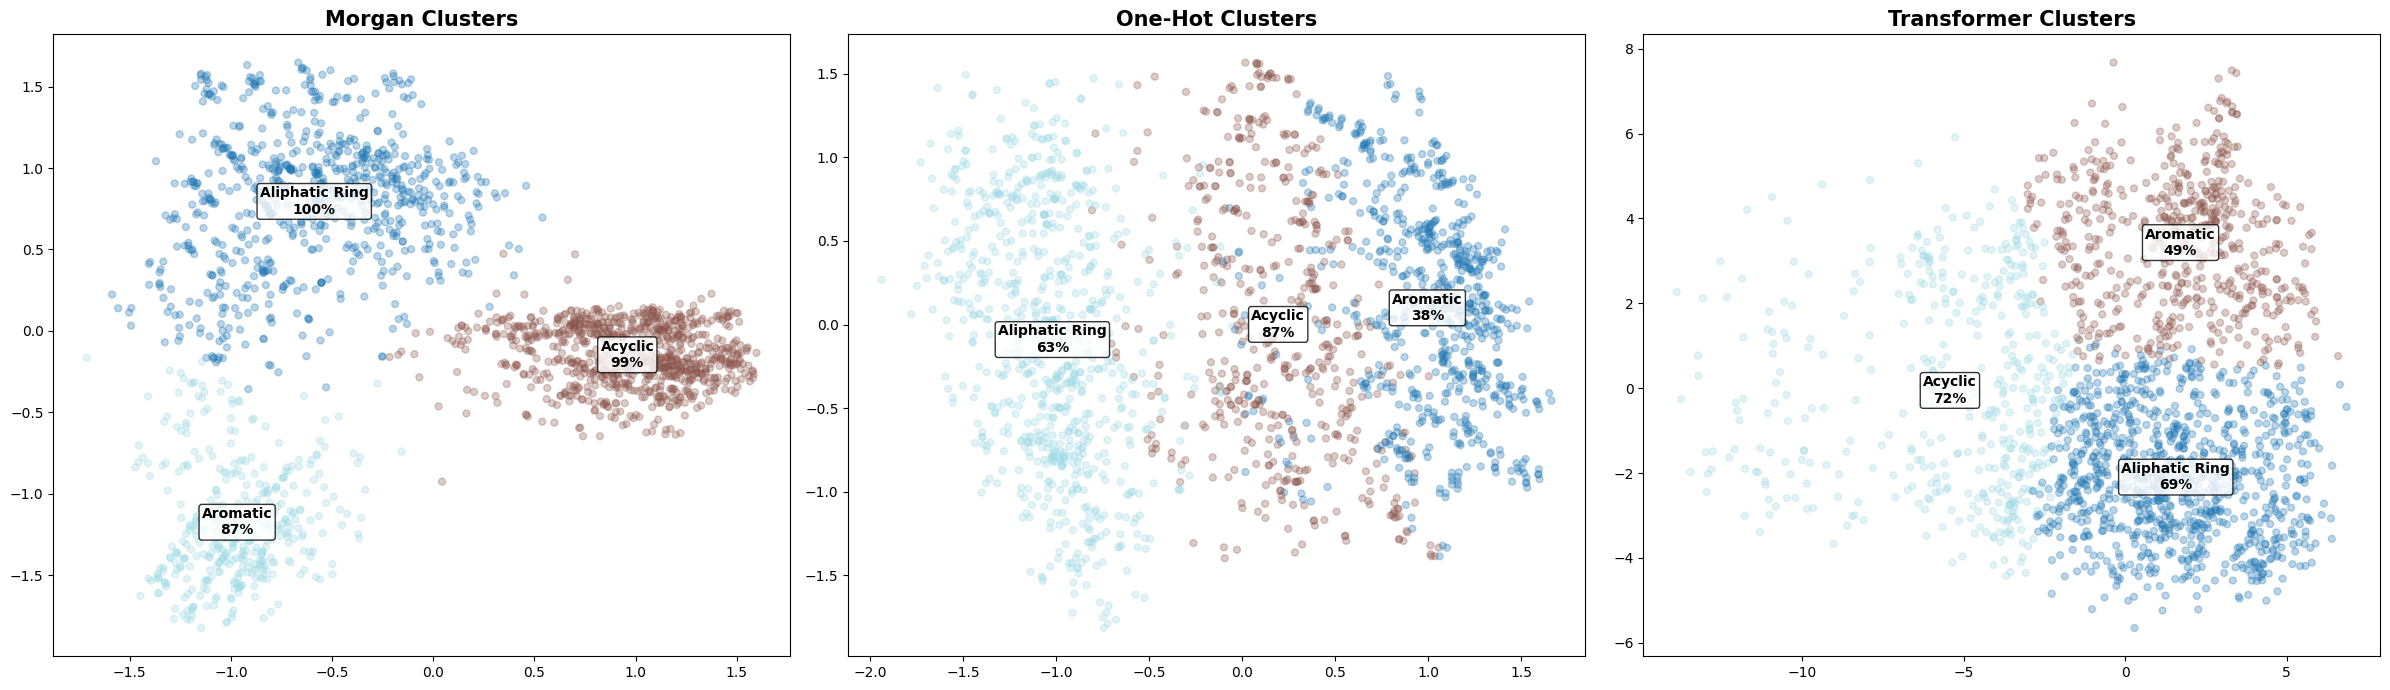

In [ ]:
analyze_molecular_clusters(qm9.df, method='kmeans')


========== ANALYZING: Morgan ==========
--- Running DBSCAN ---
skipping  dbscan

========== ANALYZING: One-Hot ==========
--- Running DBSCAN ---
skipping  dbscan

========== ANALYZING: Transformer ==========
--- Running DBSCAN ---
skipping  dbscan


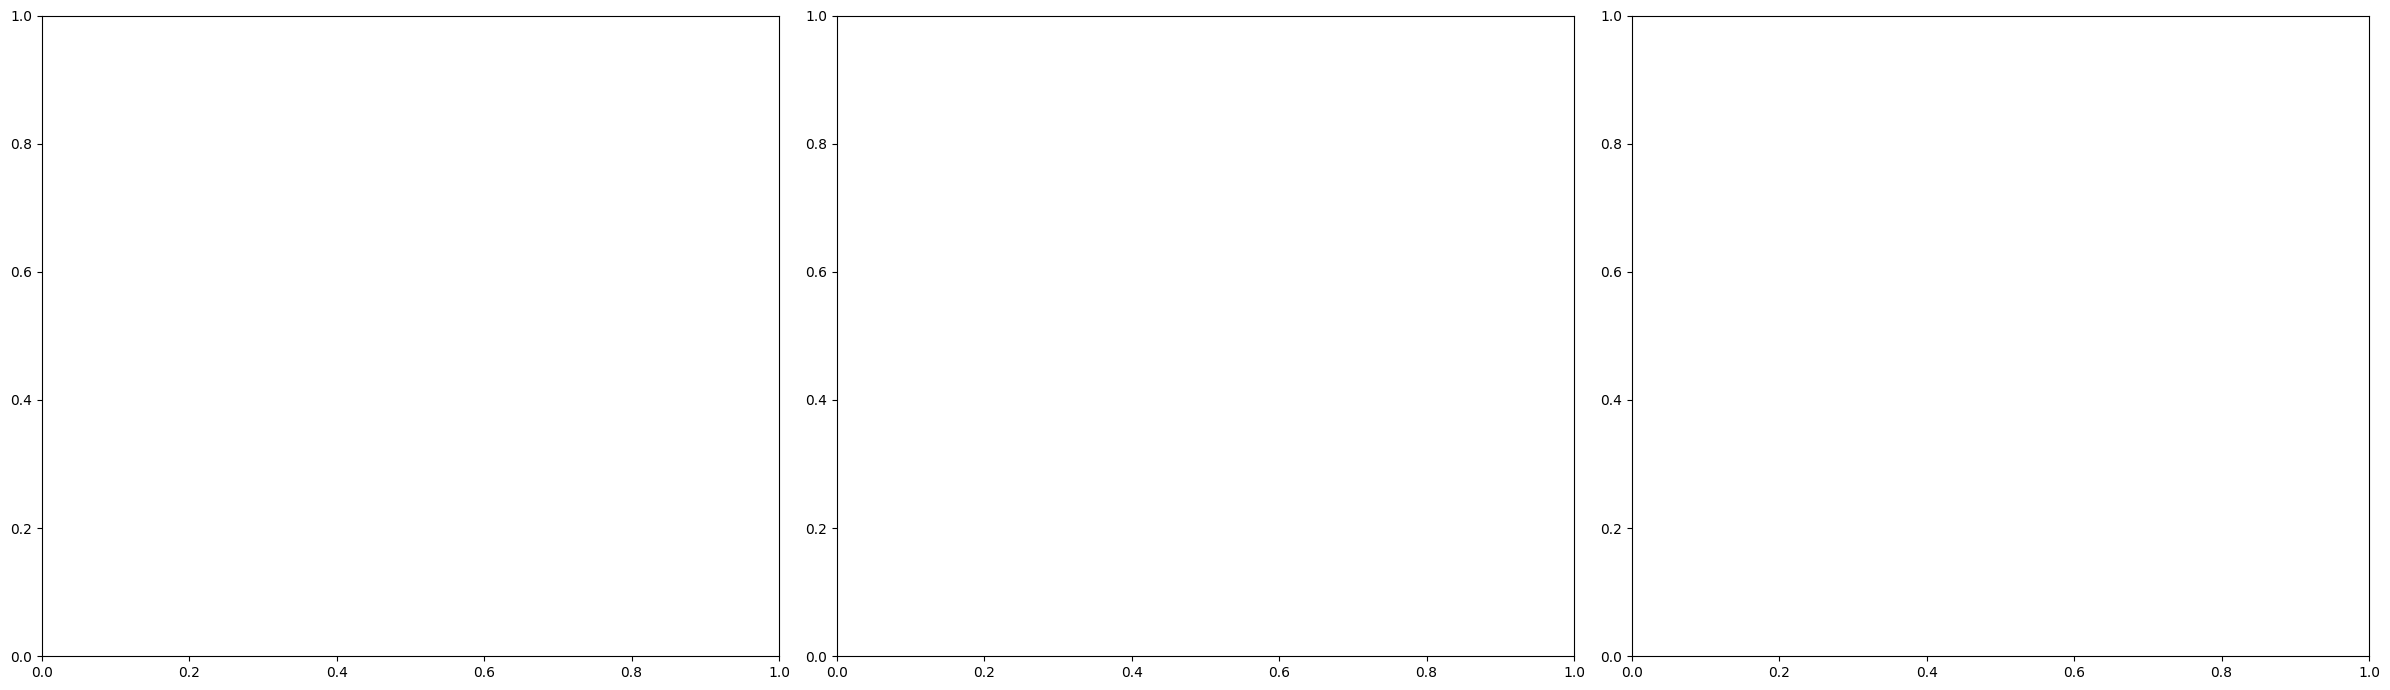

In [ ]:
analyze_molecular_clusters(qm9.df, method='dbscan')


========== ANALYZING: Morgan ==========
--- Running HIERARCHICAL ---
Found 5 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 0.5460
Silhouette Score: 0.0458
Calinski-Harabasz Score: 70.5469

--- Mismatch Analysis ---
Visual Intruders: 182 (Look like they belong elsewhere)
Silhouette Outliers: 210 (Ambiguous assignment)
Label Mismatches: 117 (Don't match cluster's dominant class)
Finding top 3 neighbors for every molecule...
Found 117 mismatches.

========== ANALYZING: One-Hot ==========
--- Running HIERARCHICAL ---
Found 5 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 0.2695
Silhouette Score: 0.0599
Calinski-Harabasz Score: 101.2170

--- Mismatch Analysis ---
Visual Intruders: 423 (Look like they belong elsewhere)
Silhouette Outliers: 361 (Ambiguous assignment)
Label Mismatches: 604 (Don't match cluster's dominant class)
Finding top 3 neighbors for every molecule...
Found 604 mismatches.

========== ANALYZING: Transformer ==========
--- Running HIERAR

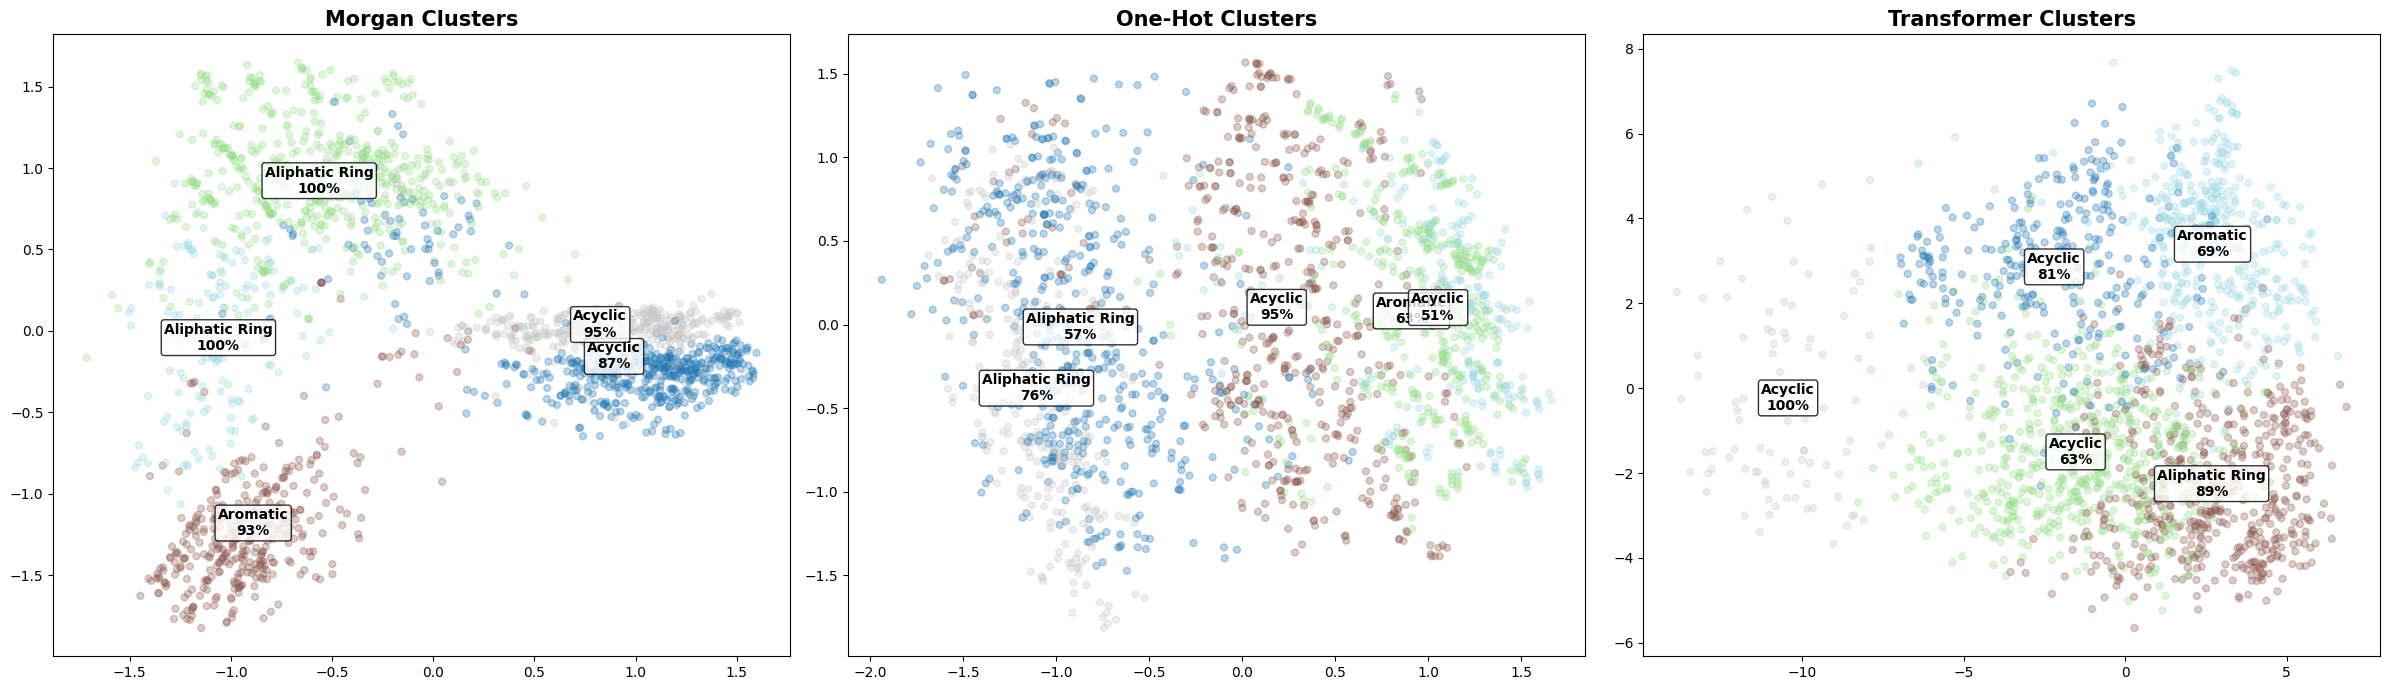

In [ ]:
analyze_molecular_clusters(qm9.df, method='hierarchical')


In [ ]:
true_labels = qm9.df['structure_class']
num_clusters = len(set(true_labels))

methods = ["morgan_fingerprint", "selfies_transformer", "selfies_onehot"]
for method in methods:
    
    X = np.array(qm9.df[method].to_list(), dtype=np.float32)

    if method == "selfies_onehot":
        X = X.reshape(X.shape[0], -1)

    analyzer = ClusterAnalysis(X, true_labels=true_labels, meta_df=qm9.df) 

    kmeans_labels = analyzer.run(method='kmeans', n_clusters=num_clusters)
    dbscan_labels = analyzer.run(method='dbscan', n_clusters=num_clusters)
    hierarchical_labels = analyzer.run(method='hierarchical', n_clusters=num_clusters)

    qm9.df = qm9.df.with_columns([
        pl.Series(f"{method}_kmeans_labels", kmeans_labels),
        pl.Series(f"{method}_dbscan_labels", dbscan_labels),
        pl.Series(f"{method}_hierarchical_labels", hierarchical_labels)
    ])

qm9.df

--- Running KMEANS ---
--- Running DBSCAN ---
--- Running HIERARCHICAL ---
--- Running KMEANS ---
--- Running DBSCAN ---
--- Running HIERARCHICAL ---
--- Running KMEANS ---
--- Running DBSCAN ---
--- Running HIERARCHICAL ---


mol_id,canonical_smiles,selfies,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp3,h_bond_donors,h_bond_acceptors,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,morgan_fingerprint,selfies_transformer,selfies_onehot,cluster_label,visual_consistency_flag,neighbor_structure_classes,pca_1,pca_2,overlap_score,dominant_neighbor,is_overlapping,morgan_kmean_labels,morgan_fingerprint_kmeans_labels,morgan_fingerprint_dbscan_labels,morgan_fingerprint_hierarchical_labels,selfies_transformer_kmeans_labels,selfies_transformer_dbscan_labels,selfies_transformer_hierarchical_labels,selfies_onehot_kmeans_labels,selfies_onehot_dbscan_labels,selfies_onehot_hierarchical_labels
str,str,str,i64,str,f64,f64,f64,i64,i64,i64,i64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[i8],list[f64],list[list[i64]],i32,bool,str,f32,f32,f64,str,bool,i32,i32,i64,i64,i32,i64,i64,i32,i64,i64
"""qm9_0""","""C""","""[C]""",5,"""Acyclic""",16.043,0.6361,0.0,1,0,0,0,1.0,0,0,0.0,13.21,-10.549854,3.186453,13.736308,35.364101,1.217682,-1101.487793,-1101.40979,-1101.384033,-1102.022949,6.469,-17.172182,-17.286823,-17.389656,-16.151918,157.711807,157.709976,157.706985,"[0, 0, … 0]","[1.116855, 0.998924, … 0.737373]","[[0, 0, … 0], [0, 0, … 1], … [0, 0, … 1]]",0,false,"""Acyclic, Acyclic, Acyclic""",-0.250427,-0.157633,0.45,"""Acyclic""",true,0,0,-1,2,2,-1,0,0,-1,1
"""qm9_1""","""N""","""[N]""",4,"""Acyclic""",17.031,0.162,35.0,1,0,0,0,0.0,1,1,1.6256,9.46,-6.993326,2.255824,9.249149,26.1563,0.934929,-1538.147705,-1538.069824,-1538.044189,-1538.666748,6.316,-12.005855,-12.082129,-12.159273,-11.246005,293.609741,293.541107,191.393967,"[0, 0, … 0]","[0.316447, 0.69667, … 1.264199]","[[0, 0, … 0], [0, 0, … 1], … [0, 0, … 1]]",0,false,"""Acyclic, Acyclic, Acyclic""",-0.252776,-0.157807,0.45,"""Acyclic""",true,0,0,-1,2,2,-1,0,0,-1,1
"""qm9_2""","""O""","""[O]""",3,"""Acyclic""",18.015,-0.8247,31.5,1,0,0,0,0.0,0,0,1.8511,6.31,-7.967494,1.869422,9.836916,19.0002,0.581643,-2079.077881,-2079.000732,-2078.975098,-2079.558105,6.002,-9.240362,-9.278811,-9.330214,-8.733849,799.588135,437.90387,282.945465,"[0, 0, … 0]","[0.08437, 0.681181, … 0.699162]","[[0, 0, … 0], [0, 0, … 1], … [0, 0, … 1]]",1,false,"""Acyclic, Acyclic, Acyclic""",-0.157225,-0.126936,0.3,"""Acyclic""",true,1,1,-1,2,2,-1,0,0,-1,1
"""qm9_3""","""C#C""","""[C][#C]""",4,"""Acyclic""",26.038,0.2494,0.0,2,0,0,0,0.0,0,0,0.0,16.280001,-7.741639,1.376896,9.118535,59.524799,0.730381,-2103.669434,-2103.590576,-2103.564697,-2104.186523,8.574,-16.716963,-16.792231,-16.869347,-15.862634,0.0,35.610035,35.610035,"[0, 0, … 0]","[0.895405, 0.401674, … 0.650952]","[[0, 0, … 0], [1, 0, … 0], … [0, 0, … 1]]",1,false,"""Acyclic, Acyclic, Acyclic""",-0.172965,-0.146954,0.3,"""Acyclic""",true,1,1,-1,2,2,-1,0,0,-1,1
"""qm9_4""","""C#N""","""[C][#N]""",3,"""Acyclic""",27.026,0.13978,23.79,2,0,0,0,0.0,0,1,2.8937,12.99,-9.806983,0.519737,10.329442,48.747601,0.451736,-2541.866943,-2541.79834,-2541.772705,-2542.393555,6.278,-13.088188,-13.13529,-13.186666,-12.520096,0.0,44.593884,44.593884,"[0, 0, … 0]","[0.981024, 0.386095, … 1.052694]","[[0, 0, … 0], [0, 1, … 0], … [0, 0, … 1]]",1,false,"""Acyclic, Acyclic, Acyclic""",-0.093187,-0.142969,0.25,"""Acyclic""",true,1,1,-1,2,2,-1,0,0,-1,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""qm9_2010""","""O=C1C=CCCN1""","""[O][=C][C][=C][C][C][N][Ring1]…",14,"""Aliphatic Ring""",97.117,0.0625,29.1,7,1,0,0,0.4,1,1,4.175,59.880001,-6.511684,-0.854437,5.657247,680.8172,3.166589,-8833.507812,-8833.344727,-8833.319336,-8834.314453,22.622999,-60.986275,-61.363506,-61.697636,-56.969707,5.0588,2.61575,1.79821,"[0, 0, … 0]","[0.299405, -0.013913, … 1.102453]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]",2,false,"""Aliphatic Ring, Aliphatic Ring…",-1.217949,-0.81956,0.45,"""Aliphatic Ring""",true,2,2,-1,1,

# Analysis overlapping clusters

--- Running KMEANS ---


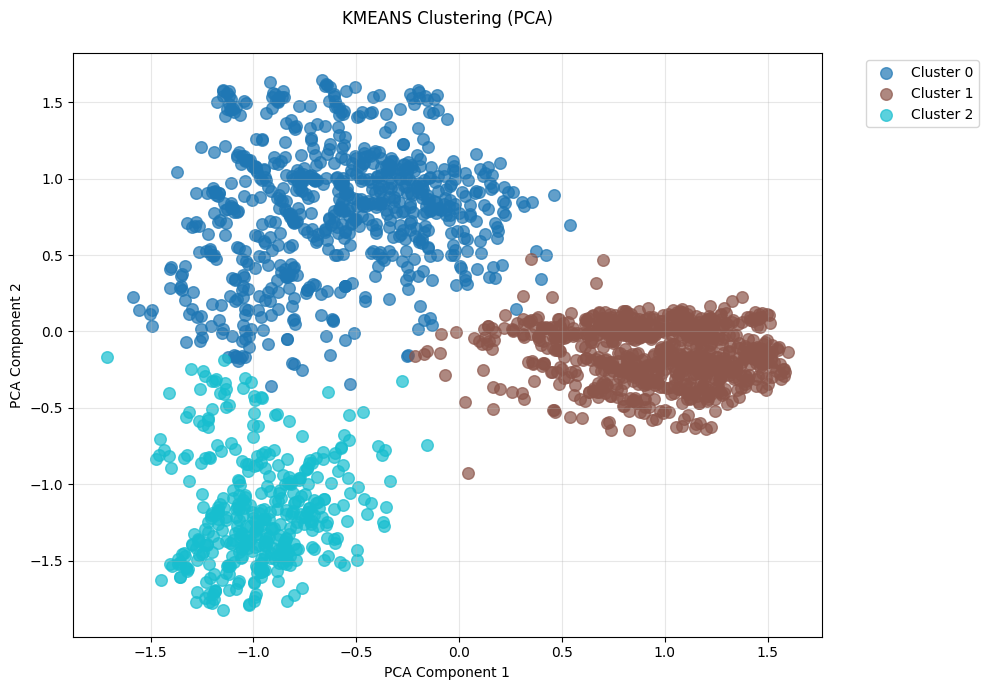

Fixed! Found 2 Aromatic molecules in Acyclic regions.


In [ ]:
import numpy as np
import polars as pl
from sklearn.neighbors import NearestNeighbors

# 1. Run Clustering (Optional, if you still need the KMeans labels)
# Ensure X is numeric (e.g., float32)
X = np.array(qm9.df["morgan_fingerprint"].to_list(), dtype=np.float32)
true_labels = qm9.df['structure_class']

# Assuming 'analyzer' is your custom class
analyzer = ClusterAnalysis(X, true_labels=true_labels, meta_df=qm9.df) 
num_clusters = len(set(true_labels))
kmeans_labels = analyzer.run(method='kmeans', n_clusters=num_clusters)

# 2. Get the 2D PCA coordinates
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X)

# 3. Analyze Overlap using Nearest Neighbors
k = 20
# fit on X_pca
nbrs = NearestNeighbors(n_neighbors=k + 1).fit(X_pca)
distances, neighbor_indices = nbrs.kneighbors(X_pca)

y_ground_truth = true_labels.to_numpy()

overlap_scores = []
dominant_neighbor_classes = []

for i, indices in enumerate(neighbor_indices):
    # indices[0] is the point itself, exclude it
    neighbors_idx = indices[1:]
    
    own_class = y_ground_truth[i]
    neighbor_classes = y_ground_truth[neighbors_idx]
    
    # Metric A: Overlap Score
    mismatch_ratio = np.mean(neighbor_classes != own_class)
    overlap_scores.append(mismatch_ratio)
    
    # Metric B: Dominant Neighbor (FIXED for Strings)
    # np.unique is robust for strings and faster than scipy.stats.mode here
    vals, counts = np.unique(neighbor_classes, return_counts=True)
    dom_class = vals[np.argmax(counts)]
    dominant_neighbor_classes.append(dom_class)

# 4. Add everything back to the Polars DataFrame
# Converting lists to pl.Series usually works best
qm9.df = qm9.df.with_columns([
    pl.Series("cluster_label", kmeans_labels),
    pl.Series("pca_1", X_pca[:, 0]),
    pl.Series("pca_2", X_pca[:, 1]),
    pl.Series("overlap_score", overlap_scores),
    pl.Series("dominant_neighbor", dominant_neighbor_classes),
    # Boolean flag: True if more than 5% of neighbors are different
    pl.Series("is_overlapping", np.array(overlap_scores) > 0.05) 
])

# 5. Plotting
analyzer.plot_pca()

# 6. Check results
confused_points = qm9.df.filter(
    (pl.col("structure_class") == "Aromatic") & 
    (pl.col("dominant_neighbor") == "Acyclic")
)
print(f"Found {len(confused_points)} Aromatic molecules in Acyclic regions.")

In [ ]:
vals, counts = np.unique(neighbor_classes, return_counts=True)
dom_class = vals[np.argmax(counts)]

'Aliphatic Ring'

In [ ]:
qm9.df

mol_id,canonical_smiles,selfies,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp3,h_bond_donors,h_bond_acceptors,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,morgan_fingerprint,selfies_transformer,selfies_onehot,cluster_label,visual_consistency_flag,neighbor_structure_classes
str,str,str,i64,str,f64,f64,f64,i64,i64,i64,i64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[i8],list[f64],list[list[i64]],i32,bool,str
"""qm9_0""","""C""","""[C]""",5,"""Acyclic""",16.043,0.6361,0.0,1,0,0,0,1.0,0,0,0.0,13.21,-10.549854,3.186453,13.736308,35.364101,1.217682,-1101.487793,-1101.40979,-1101.384033,-1102.022949,6.469,-17.172182,-17.286823,-17.389656,-16.151918,157.711807,157.709976,157.706985,"[0, 0, … 0]","[1.116855, 0.998924, … 0.737373]","[[0, 0, … 0], [0, 0, … 1], … [0, 0, … 1]]",0,false,"""Acyclic, Acyclic, Acyclic"""
"""qm9_1""","""N""","""[N]""",4,"""Acyclic""",17.031,0.162,35.0,1,0,0,0,0.0,1,1,1.6256,9.46,-6.993326,2.255824,9.249149,26.1563,0.934929,-1538.147705,-1538.069824,-1538.044189,-1538.666748,6.316,-12.005855,-12.082129,-12.159273,-11.246005,293.609741,293.541107,191.393967,"[0, 0, … 0]","[0.316447, 0.69667, … 1.264199]","[[0, 0, … 0], [0, 0, … 1], … [0, 0, … 1]]",0,false,"""Acyclic, Acyclic, Acyclic"""
"""qm9_2""","""O""","""[O]""",3,"""Acyclic""",18.015,-0.8247,31.5,1,0,0,0,0.0,0,0,1.8511,6.31,-7.967494,1.869422,9.836916,19.0002,0.581643,-2079.077881,-2079.000732,-2078.975098,-2079.558105,6.002,-9.240362,-9.278811,-9.330214,-8.733849,799.588135,437.90387,282.945465,"[0, 0, … 0]","[0.08437, 0.681181, … 0.699162]","[[0, 0, … 0], [0, 0, … 1], … [0, 0, … 1]]",1,false,"""Acyclic, Acyclic, Acyclic"""
"""qm9_3""","""C#C""","""[C][#C]""",4,"""Acyclic""",26.038,0.2494,0.0,2,0,0,0,0.0,0,0,0.0,16.280001,-7.741639,1.376896,9.118535,59.524799,0.730381,-2103.669434,-2103.590576,-2103.564697,-2104.186523,8.574,-16.716963,-16.792231,-16.869347,-15.862634,0.0,35.610035,35.610035,"[0, 0, … 0]","[0.895405, 0.401674, … 0.650952]","[[0, 0, … 0], [1, 0, … 0], … [0, 0, … 1]]",1,false,"""Acyclic, Acyclic, Acyclic"""
"""qm9_4""","""C#N""","""[C][#N]""",3,"""Acyclic""",27.026,0.13978,23.79,2,0,0,0,0.0,0,1,2.8937,12.99,-9.806983,0.519737,10.329442,48.747601,0.451736,-2541.866943,-2541.79834,-2541.772705,-2542.393555,6.278,-13.088188,-13.13529,-13.186666,-12.520096,0.0,44.593884,44.593884,"[0, 0, … 0]","[0.981024, 0.386095, … 1.052694]","[[0, 0, … 0], [0, 1, … 0], … [0, 0, … 1]]",1,false,"""Acyclic, Acyclic, Acyclic"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""qm9_2010""","""O=C1C=CCCN1""","""[O][=C][C][=C][C][C][N][Ring1]…",14,"""Aliphatic Ring""",97.117,0.0625,29.1,7,1,0,0,0.4,1,1,4.175,59.880001,-6.511684,-0.854437,5.657247,680.8172,3.166589,-8833.507812,-8833.344727,-8833.319336,-8834.314453,22.622999,-60.986275,-61.363506,-61.697636,-56.969707,5.0588,2.61575,1.79821,"[0, 0, … 0]","[0.299405, -0.013913, … 1.102453]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]",2,false,"""Aliphatic Ring, Aliphatic Ring…"
"""qm9_2011""","""O=C1C=CCCO1""","""[O][=C][C][=C][C][C][O][Ring1]…",13,"""Aliphatic Ring""",98.101,0.4895,26.3,7,1,0,0,0.4,0,2,4.8544,56.209999,-7.159316,-1.257166,5.90215,655.236389,2.820787,-9374.298828,-9374.142578,-9374.116211,-9375.104492,21.473,-58.082684,-58.426769,-58.735184,-54.355564,5.15103,2.69583,1.85565,"[0, 0, … 0]","[0.233892, 0.030704, … 1.002681]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]",2,false,"""Aliphatic Ring, Aliphatic Ring…"
"""qm9_2012""","""[NH-][C@H]1CCCCO1""","""[NH1-1][C@H1][C][C][C][C][O][R…",16,"""Aliphatic Ring""",100.141,1.5652,33.03,7,1,0,0,1.0,0,1,3.2084,62.029999,-6.908971,0.634025,7.542996,719.927979,3.796587,-8865.521484,-8865.349609,-8865.324219,-8866.344727,23.990999,-65.773956,-66.218506,-66.604065,-61.192863,4.58056,2.56496,1.77558,"[0, 0, … 0]","[0.537106, -0.137771, … 0.598195]","[[0, 0, … 0], [0, 0, … 0], … 